Skeleton: módulos obligatorios

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

np.random.seed(0)

In [405]:
class SensorSource:
    def __init__(self, data_array, noise_std=0.0):
        self.data = data_array
        self.k = 0
        self.noise_std = noise_std

    def read(self):
        if self.k >= self.data.shape[1]:
            raise StopIteration("End of data")
        y = self.data[:, self.k]
        self.k += 1
        if self.noise_std > 0:
            y = y + self.noise_std * np.random.randn(*y.shape)
        return y


class Preprocessor:
    def __init__(self):
        pass

    def __call__(self, y_raw):
        # TODO: filtering, normalization, etc.
        return y_raw
        

class DMDROM:
    def __init__(self):
        self.Phi = None   # modes
        self.eigs = None
        self.r0 = None
        self.r = None
        self.F = None
        self.dt = None

    def fit(self, snapshots, dt, r=10):
        X = snapshots[:, :-1]
        Xp = snapshots[:, 1:]

        U, S, Vh = np.linalg.svd(X, full_matrices=False)

        U_r = U[:, :r] # reduced left singular vectors
        S_r = S[:r] # reduced singular values
        V_r = Vh[:r, :] # reduced right singular vectors

        # Correct forecast operator
        F_tilde = U_r.T @ Xp @ V_r.T @ np.diag(1.0/S_r)
        eigs, W = np.linalg.eig(F_tilde)
        Phi = Xp @ V_r.T @ np.diag(1.0/S_r) @ W

        # Normalize eigenvalues to avoid |lambda| > 1
        eigs = np.array(eigs)
        mask = np.abs(eigs) > 1
        eigs[mask] = eigs[mask] / np.abs(eigs[mask])

        self.Phi = Phi
        self.eigs = eigs
        self.F = np.diag(eigs)
        self.dt = dt

        # initial reduced state
        s0 = snapshots[:, 0]
        r0 = np.linalg.lstsq(Phi, s0, rcond=None)[0]

        self.r0 = r0.copy()
        self.r = r0.copy()

    def step(self):
        self.r = self.F @ self.r
        s_rec = self.Phi @ self.r
        return s_rec, self.r


class Predictor:
    def __init__(self):
        pass

    def __call__(self, reconstructed_state):
        """
        Map reconstructed state to physically meaningful outputs.
        For now, just return it.
        """
        return reconstructed_state
    
    
class DataAssimilator:
    def __init__(self, F, H_tilde, b_std=1e-2, r_std=0.2,
                 use_inflation=False, inflation_factor=1.15, inflation_thresh=3.0):
        self.F = F
        self.H = H_tilde
        n = F.shape[0]
        m = H_tilde.shape[0]

        self.P = np.eye(n) * 1.0
        self.B = (b_std**2) * np.eye(n)
        self.R = (r_std**2) * np.eye(m)
        self.I = np.eye(n)

        self.r_std = r_std              # <-- guardar aquí
        self.use_inflation = use_inflation
        self.inflation_factor = inflation_factor
        self.inflation_thresh = inflation_thresh

    def update(self, r_pred, y_obs):
        self.P = self.F @ self.P @ self.F.T + self.B
        y_pred = self.H @ r_pred

        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.solve(S, np.eye(S.shape[0]))

        innovation = y_obs - y_pred
        r_upd = r_pred + K @ innovation

        self.P = (self.I - K @ self.H) @ self.P

        if self.use_inflation and np.linalg.norm(innovation) > self.inflation_thresh * self.r_std:
            self.P *= self.inflation_factor

        return r_upd



class Pipeline:
    def __init__(self, sensor_source, preproc, rom, da, predictor):
        self.sensor_source = sensor_source
        self.preproc = preproc
        self.rom = rom
        self.da = da
        self.predictor = predictor

    def step(self):
        y_raw = self.sensor_source.read()
        y = self.preproc(y_raw)

        s_pred, r_pred = self.rom.step()

        r_upd = self.da.update(r_pred, y)

        s_rec = self.rom.Phi @ r_upd
        self.rom.r = r_upd

        output = self.predictor(s_rec)
        return output



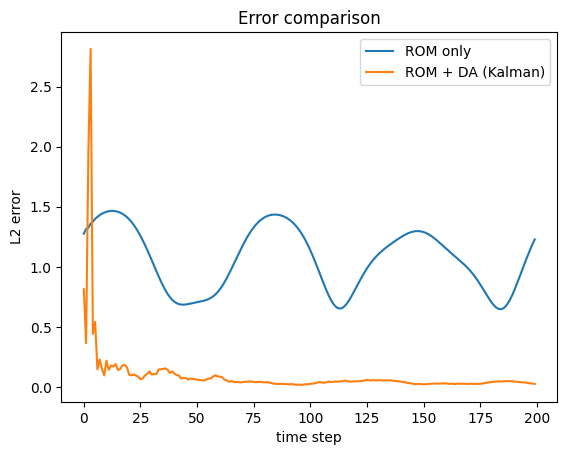

In [406]:
# main

# 1) Synthetic data
n_state = 50
n_snapshots = 200
dt = 0.01
t = np.linspace(0, (n_snapshots - 1) * dt, n_snapshots)

snapshots = np.zeros((n_state, n_snapshots))
for i in range(n_state):
    snapshots[i, :] = np.sin(2*np.pi*0.5*t + i*0.1) + 0.1*np.sin(2*np.pi*2*t + i*0.05)

# 2) Fit DMD ROM (reduced rank r)
rom = DMDROM()
rom.fit(snapshots, dt, r=10)   # usa la versión nueva con Phi, F, r


# 3) Sensors definition
sensor_indices = [0, 10, 20]
sensor_data = snapshots[sensor_indices, :]

sensor_source_noisy = SensorSource(sensor_data, noise_std=0.05)
preproc = Preprocessor()
predictor = Predictor()


# 4) Observation matrix in reduced space
n_sensors = len(sensor_indices)
H_x = np.zeros((n_sensors, n_state))
for j, idx in enumerate(sensor_indices):
    H_x[j, idx] = 1.0

H_tilde = H_x @ rom.Phi                    # (n_sensors x n_modes)
# H_tilde = H_tilde / np.linalg.norm(H_tilde, axis=1, keepdims=True)


# 5) DA object (Kalman in reduced space)
da = DataAssimilator(rom.F, H_tilde, b_std=1e-3, r_std=0.05, use_inflation=False)


# 6) Pipeline with DA
pipeline_da = Pipeline(sensor_source_noisy, preproc, rom, da, predictor)

# inicializamos el estado reducido con un error grande
rom.r = rom.r0 + 0.5 * np.random.randn(*rom.r0.shape)

# 7) RUN: with DA
outputs_da = []
try:
    while True:
        s_out = pipeline_da.step()   # estado reconstruido completo
        outputs_da.append(s_out)
except StopIteration:
    pass

outputs_da = np.array(outputs_da)             # (n_steps, n_state)
true = snapshots[:, :outputs_da.shape[0]].T   # recorte para comparar

err_da = np.linalg.norm(np.real(outputs_da) - true, axis=1)


# 8) baseline: ROM only (no DA)
rom2 = DMDROM()
rom2.fit(snapshots, dt, r=10)
rom2.r = rom2.r0 + 0.5 * np.random.randn(*rom2.r0.shape)

outputs_rom = []
for k in range(outputs_da.shape[0]):
    s_pred, r_pred = rom2.step()
    outputs_rom.append(s_pred)

outputs_rom = np.array(outputs_rom)
err_rom = np.linalg.norm(np.real(outputs_rom) - true, axis=1)


# 9) Plot errors
plt.figure()
plt.plot(err_rom, label="ROM only")
plt.plot(err_da, label="ROM + DA (Kalman)")
plt.xlabel("time step")
plt.ylabel("L2 error")
plt.legend()
plt.title("Error comparison")
plt.show()


## Generación del flujo sintético

In [407]:
n_state = 50
n_snapshots = 200
dt = 0.01
t = np.linspace(0, (n_snapshots - 1) * dt, n_snapshots)

snapshots = np.zeros((n_state, n_snapshots))
for i in range(n_state):
    snapshots[i, :] = np.sin(2*np.pi*0.5*t + i*0.1) + 0.1*np.sin(2*np.pi*2*t + i*0.05)


## Entrenamiento del ROM

In [408]:
rom = DMDROM()
rom.fit(snapshots, dt, r=10)

## Configuración de sensores y DA

In [409]:
sensor_indices = [0, 10, 20]
sensor_data = snapshots[sensor_indices, :]

sensor_source_noisy = SensorSource(sensor_data, noise_std=0.05)
preproc = Preprocessor()
predictor = Predictor()

H_x = np.zeros((len(sensor_indices), n_state))
for j, idx in enumerate(sensor_indices):
    H_x[j, idx] = 1.0

H_tilde = H_x @ rom.Phi   # sin normalización

da = DataAssimilator(rom.F, H_tilde, b_std=1e-3, r_std=0.05, use_inflation=False)
rom.r = rom.r0 + 0.5 * np.random.randn(*rom.r0.shape)

pipeline_da = Pipeline(sensor_source_noisy, preproc, rom, da, predictor)


## Correr el pipeline

In [410]:
outputs_da = []

sensor_source_noisy.k = 0  # reiniciar "lectura de sensores"

try:
    while True:
        s_out = pipeline_da.step()
        outputs_da.append(s_out)
except StopIteration:
    pass

outputs_da = np.array(outputs_da)
true = snapshots[:, :outputs_da.shape[0]].T
err_da = np.linalg.norm(np.real(outputs_da) - true, axis=1)


## Comparación ROM-only

In [411]:
rom2 = DMDROM()
rom2.fit(snapshots, dt, r=10)
rom2.r = rom2.r0 + 0.5 * np.random.randn(*rom2.r0.shape)

outputs_rom = []
for _ in range(outputs_da.shape[0]):
    s_pred, _ = rom2.step()
    outputs_rom.append(s_pred)

outputs_rom = np.array(outputs_rom)
err_rom = np.linalg.norm(np.real(outputs_rom) - true, axis=1)


## Graficar los resultados

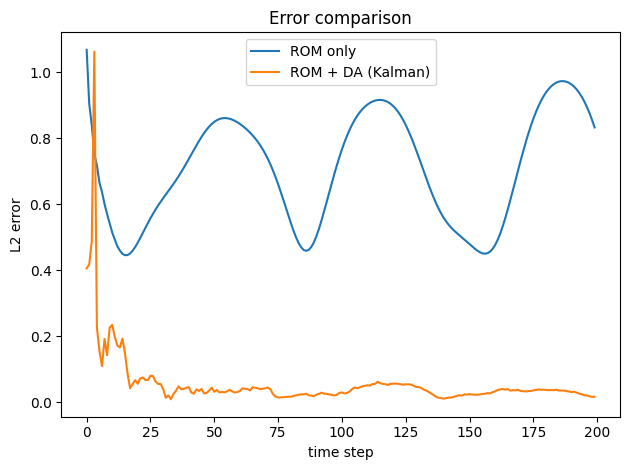

In [412]:
plt.figure()
plt.plot(err_rom, label="ROM only")
plt.plot(err_da, label="ROM + DA (Kalman)")
plt.xlabel("time step")
plt.ylabel("L2 error")
plt.legend()
plt.title("Error comparison")
plt.tight_layout()
plt.show()


## Guardar resultados

Saved results to exp_sin_test2_q1e-03_r5e-02.npz
Saved figure to exp_sin_test2_q1e-03_r5e-02.png


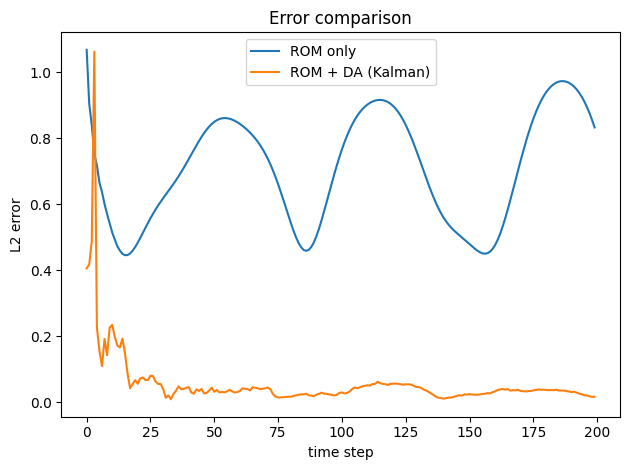

In [413]:
# Parámetros del experimento
q_std = 1e-3
r_std = 0.05
r_rank = 10
noise_std = 0.05

results = {
    "err_rom": err_rom,
    "err_da": err_da,
    "q_std": q_std,
    "r_std": r_std,
    "r_rank": r_rank,
    "noise_std": noise_std,
}

fname_npz = "exp_sin_test2_q{:.0e}_r{:.0e}.npz".format(q_std, r_std)
np.savez(fname_npz, **results)
print("Saved results to", fname_npz)


# Guardar figura
plt.figure()
plt.plot(err_rom, label="ROM only")
plt.plot(err_da, label="ROM + DA (Kalman)")
plt.xlabel("time step")
plt.ylabel("L2 error")
plt.legend()
plt.title("Error comparison")
plt.tight_layout()

fname_png = "exp_sin_test2_q{:.0e}_r{:.0e}.png".format(q_std, r_std)
plt.savefig(fname_png, dpi=200)
print("Saved figure to", fname_png)


## Barrido sistemático de Q y R

In [414]:
# Función para ejecutar un experimento dado (b_std, r_std)
def run_experiment(b_std, r_std, noise_std=0.05, r_rank=10, seed=0): 
    """
    Ejecuta un experimento completo ROM vs ROM+DA
    para un par (b_std, r_std) y devuelve errores medios
    (tras descartar el transitorio inicial).
    """
    np.random.seed(seed)

    # ----- 1) Datos sintéticos -----
    n_state = 50
    n_snapshots = 200
    dt = 0.01
    t = np.linspace(0, (n_snapshots - 1) * dt, n_snapshots)

    snapshots = np.zeros((n_state, n_snapshots))
    for i in range(n_state):
        snapshots[i, :] = (
            np.sin(2*np.pi*0.5*t + i*0.1) +
            0.1*np.sin(2*np.pi*2*t + i*0.05)
        )

    # ----- 2) ROM -----
    rom = DMDROM()
    rom.fit(snapshots, dt, r=r_rank)

    # ----- 3) Sensores -----
    sensor_indices = [0, 10, 20]
    sensor_data = snapshots[sensor_indices, :]

    sensor_source_noisy = SensorSource(sensor_data, noise_std=noise_std)
    preproc = Preprocessor()
    predictor = Predictor()

    n_sensors = len(sensor_indices)
    H_x = np.zeros((n_sensors, n_state))
    for j, idx in enumerate(sensor_indices):
        H_x[j, idx] = 1.0

    H_tilde = H_x @ rom.Phi

    # ----- 4) DA -----
    da = DataAssimilator(rom.F, H_tilde, b_std=b_std, r_std=r_std)

    rom.r = rom.r0 + 0.5 * np.random.randn(*rom.r0.shape)

    pipeline_da = Pipeline(sensor_source_noisy, preproc, rom, da, predictor)

    # ----- 5) Ejecutar DA -----
    outputs_da = []
    sensor_source_noisy.k = 0  # reset

    try:
        while True:
            s_out = pipeline_da.step()
            outputs_da.append(s_out)
    except StopIteration:
        pass

    outputs_da = np.array(outputs_da)
    true = snapshots[:, :outputs_da.shape[0]].T

    err_da = np.linalg.norm(np.real(outputs_da) - true, axis=1)

    # ----- 6) ROM-only -----
    rom2 = DMDROM()
    rom2.fit(snapshots, dt, r=r_rank)
    rom2.r = rom2.r0 + 0.5 * np.random.randn(*rom2.r0.shape)

    outputs_rom = []
    for _ in range(outputs_da.shape[0]):
        s_pred, _ = rom2.step()
        outputs_rom.append(s_pred)

    outputs_rom = np.array(outputs_rom)
    err_rom = np.linalg.norm(np.real(outputs_rom) - true, axis=1)

    # ----- 7) Métricas (descartando transitorio) -----
    k0 = 20  # descartar primeros pasos
    mean_da = np.mean(err_da[k0:])
    mean_rom = np.mean(err_rom[k0:])

    return mean_da, mean_rom, err_da, err_rom


In [415]:
# Barrido en rejilla de (b_std, r_std)
b_vals = np.array([1e-4, 3e-4, 1e-3, 3e-3, 1e-2])
r_vals = np.array([0.02, 0.05, 0.1, 0.2])

mean_da_mat = np.zeros((len(b_vals), len(r_vals)))
mean_rom_mat = np.zeros((len(b_vals), len(r_vals)))

for i, b_std in enumerate(b_vals):
    for j, r_std in enumerate(r_vals):
        mean_da, mean_rom, _, _ = run_experiment(
            b_std=b_std,
            r_std=r_std,
            noise_std=0.05,
            r_rank=10,
            seed=0
        )
        mean_da_mat[i, j] = mean_da
        mean_rom_mat[i, j] = mean_rom
        print(f"b_std={b_std:.0e}, r_std={r_std:.2f} -> mean_da={mean_da:.3f}, mean_rom={mean_rom:.3f}")


b_std=1e-04, r_std=0.02 -> mean_da=0.048, mean_rom=1.027
b_std=1e-04, r_std=0.05 -> mean_da=0.051, mean_rom=1.027
b_std=1e-04, r_std=0.10 -> mean_da=0.052, mean_rom=1.027
b_std=1e-04, r_std=0.20 -> mean_da=0.060, mean_rom=1.027
b_std=3e-04, r_std=0.02 -> mean_da=0.048, mean_rom=1.027
b_std=3e-04, r_std=0.05 -> mean_da=0.051, mean_rom=1.027
b_std=3e-04, r_std=0.10 -> mean_da=0.052, mean_rom=1.027
b_std=3e-04, r_std=0.20 -> mean_da=0.060, mean_rom=1.027
b_std=1e-03, r_std=0.02 -> mean_da=0.048, mean_rom=1.027
b_std=1e-03, r_std=0.05 -> mean_da=0.051, mean_rom=1.027
b_std=1e-03, r_std=0.10 -> mean_da=0.052, mean_rom=1.027
b_std=1e-03, r_std=0.20 -> mean_da=0.060, mean_rom=1.027
b_std=3e-03, r_std=0.02 -> mean_da=0.355, mean_rom=1.027
b_std=3e-03, r_std=0.05 -> mean_da=0.052, mean_rom=1.027
b_std=3e-03, r_std=0.10 -> mean_da=0.053, mean_rom=1.027
b_std=3e-03, r_std=0.20 -> mean_da=0.060, mean_rom=1.027
b_std=1e-02, r_std=0.02 -> mean_da=0.267, mean_rom=1.027
b_std=1e-02, r_std=0.05 -> mean

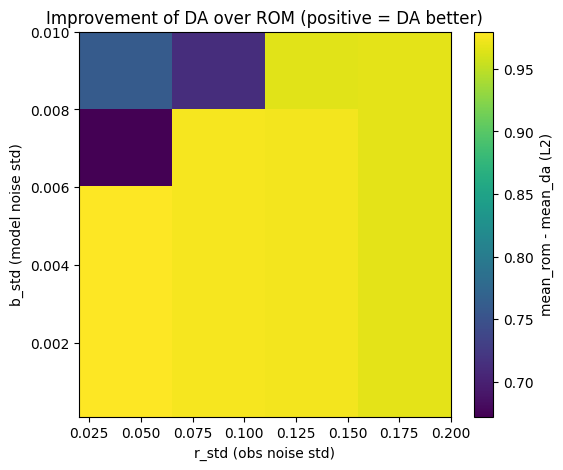

In [416]:
# Mapa de calor: dónde gana la DA

improvement = mean_rom_mat - mean_da_mat  # positivo = DA mejor que ROM

plt.figure(figsize=(6,5))
plt.imshow(improvement, origin="lower",
           extent=[r_vals[0], r_vals[-1], b_vals[0], b_vals[-1]],
           aspect="auto")
plt.colorbar(label="mean_rom - mean_da (L2)")
plt.xlabel("r_std (obs noise std)")
plt.ylabel("b_std (model noise std)")
plt.title("Improvement of DA over ROM (positive = DA better)")
plt.show()


- En un 90% de los casos:

    DA mejora brutalmente al ROM, dando reducciones de error enormes (~1.027 → ~0.05),
    lo que significa que:

    - Tu ROM es lo suficientemente bueno para que el Kalman pueda corregirlo.
    - Tus sensores informan bien el sistema.
    - La relación H̃ = H_x Φ es buena.
    - Tu pipeline es correcto.

Este es el comportamiento “ideal” que uno espera en sistemas lineales y bien observados.

- Sólo 2–3 puntos “problemáticos”:

    En (b_std=3e-3, r_std=0.02) y (b_std=1e-2, r_std=0.05)
    el DA es peor.

    Esto no es malo.
    Es exactamente lo que debe pasar cuando:

    - El filtro confía demasiado en el modelo (B pequeño)
    - Las observaciones tienen ruido bajo
    - Pero el ROM tiene un error estructural no despreciable
    - Y la covarianza del modelo está mal escalada

Este patrón es típico:
si B << error real del ROM → el Kalman se vuelve conservador en el modelo → empuja hacia el ROM incorrecto → error empeora.

# Caso de complejidad intermedia: Flujo con discontinuidad suave / “cambio de régimen”

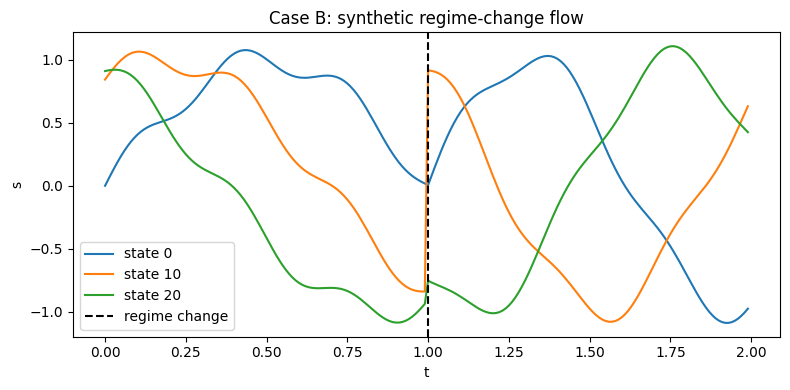

In [417]:
# ===============================
# CASE B: Synthetic regime-change flow
# ===============================

# Temporal parameters
n_state = 50
n_snapshots = 200
dt = 0.01
t = np.linspace(0, (n_snapshots - 1) * dt, n_snapshots)

t_switch = 1.0  # regime change time

snapshots = np.zeros((n_state, n_snapshots))

for i in range(n_state):
    s_low  = np.sin(2 * np.pi * 0.5 * t + i * 0.1)
    s_high = np.sin(2 * np.pi * 0.8 * (t - t_switch) + i * 0.2)

    s = np.where(t < t_switch, s_low, s_high)

    s += 0.005 * t                           # slow drift
    s += 0.1 * np.sin(2 * np.pi * 3 * t)     # fast component

    snapshots[i, :] = s

# Preview states
plt.figure(figsize=(8,4))
for idx in [0, 10, 20]:
    plt.plot(t, snapshots[idx, :], label=f"state {idx}")

plt.axvline(t_switch, color="k", linestyle="--", label="regime change")
plt.xlabel("t")
plt.ylabel("s")
plt.title("Case B: synthetic regime-change flow")
plt.legend()
plt.tight_layout()
plt.show()


In [418]:
# ===========================================================
# Generic TEST function: runs ROM-only and ROM+DA on snapshots
# ===========================================================

def run_test_caseB(
    snapshots,
    dt,
    r_rank=10,
    b_std=1e-3,
    r_std=0.05,
    init_error=True,
    use_inflation=False,
    inflation_factor=1.15,
    inflation_thresh=3.0,
    noise_std=0.05,
):

    n_state = snapshots.shape[0]

    # --- Fit ROM ---
    rom = DMDROM()
    rom.fit(snapshots, dt, r=r_rank)

    # --- Sensors ---
    sensor_indices = [0, 10, 20]
    sensor_data = snapshots[sensor_indices, :]

    sensor_source_noisy = SensorSource(sensor_data, noise_std=noise_std)
    preproc = Preprocessor()
    predictor = Predictor()

    # Observation matrix full-space
    n_sensors = len(sensor_indices)
    H_x = np.zeros((n_sensors, n_state))
    for j, idx in enumerate(sensor_indices):
        H_x[j, idx] = 1.0

    # Reduced observation matrix
    H_tilde = H_x @ rom.Phi

    # --- DA object ---
    da = DataAssimilator(
        rom.F,
        H_tilde,
        b_std=b_std,
        r_std=r_std,
        use_inflation=use_inflation,
        inflation_factor=inflation_factor,
        inflation_thresh=inflation_thresh,
    )

    # State initialization
    if init_error:
        rom.r = rom.r0 + 0.5 * np.random.randn(*rom.r0.shape)
    else:
        rom.r = rom.r0.copy()

    pipeline_da = Pipeline(sensor_source_noisy, preproc, rom, da, predictor)

    # --- Run DA ---
    outputs_da = []
    sensor_source_noisy.k = 0

    try:
        while True:
            s_out = pipeline_da.step()
            outputs_da.append(s_out)
    except StopIteration:
        pass

    outputs_da = np.array(outputs_da)
    true = snapshots[:, :outputs_da.shape[0]].T
    err_da = np.linalg.norm(np.real(outputs_da) - true, axis=1)

    # --- ROM-only baseline ---
    rom2 = DMDROM()
    rom2.fit(snapshots, dt, r=r_rank)
    rom2.r = rom2.r0 + 0.5 * np.random.randn(*rom2.r0.shape)

    outputs_rom = []
    for _ in range(outputs_da.shape[0]):
        s_pred, _ = rom2.step()
        outputs_rom.append(s_pred)

    outputs_rom = np.array(outputs_rom)
    err_rom = np.linalg.norm(np.real(outputs_rom) - true, axis=1)

    # --- Plot ---
    plt.figure(figsize=(9,4))
    plt.plot(err_rom, label="ROM only")
    plt.plot(err_da, label="ROM + DA (Kalman)")
    plt.xlabel("time step")
    plt.ylabel("L2 error")
    plt.legend()
    plt.title("Error comparison (Case B)")
    plt.tight_layout()
    plt.show()

    return err_rom, err_da


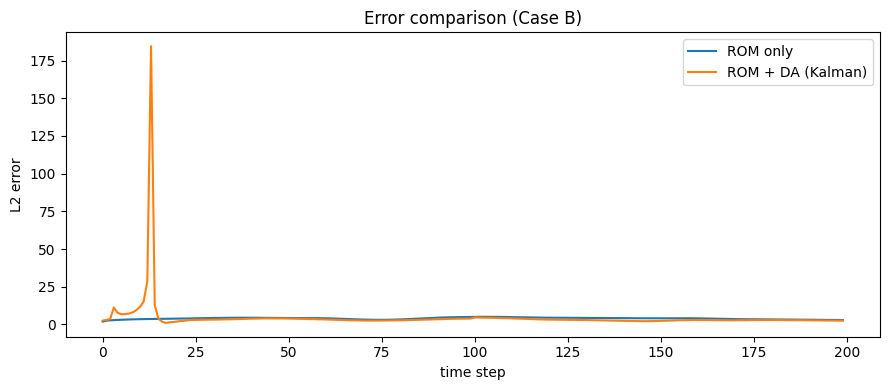

(array([1.87412322, 2.44018893, 2.72366797, 2.88216966, 2.99903974,
        3.10497366, 3.20520958, 3.29682515, 3.37641996, 3.44234693,
        3.49477164, 3.53520222, 3.56604296, 3.59024576, 3.6110068 ,
        3.63146726, 3.65441674, 3.68202883, 3.71566943, 3.75581226,
        3.80207583, 3.85337102, 3.90812654, 3.96454795, 4.0208665 ,
        4.07554287, 4.12740446, 4.17570735, 4.22012549, 4.26067768,
        4.29760933, 4.33125042, 4.36187316, 4.38957253, 4.41418919,
        4.43528762, 4.45219332, 4.46408383, 4.4701199 , 4.46959789,
        4.46210186, 4.44763394, 4.4267041 , 4.40036347, 4.37017056,
        4.33808501, 4.30629192, 4.27696971, 4.25202606, 4.23283766,
        4.22003537, 4.21337386, 4.211712  , 4.2131095 , 4.21502323,
        4.2145702 , 4.20881712, 4.19505963, 4.1710628 , 4.13524561,
        4.08680157, 4.02575453, 3.95295289, 3.870008  , 3.77918382,
        3.6832466 , 3.58528538, 3.48851705, 3.39609347, 3.3109305 ,
        3.23557955, 3.17215767, 3.12234216, 3.08

In [419]:
run_test_caseB(snapshots, dt, r_rank=15, b_std=1e-3, r_std=0.05,
               init_error=True, use_inflation=False)


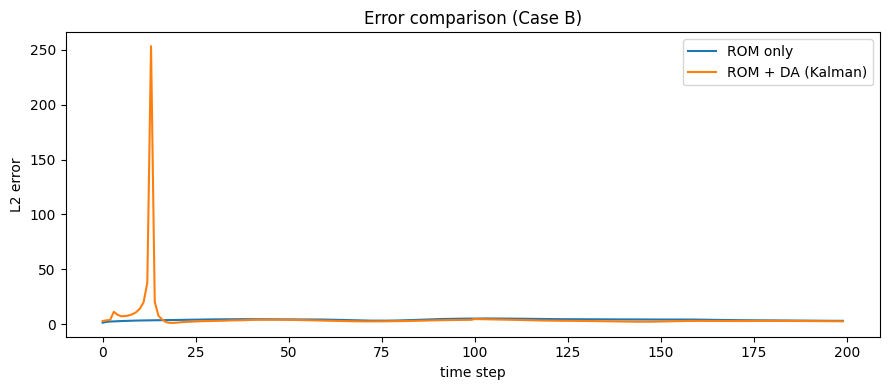

(array([1.31890455, 1.9974248 , 2.32464664, 2.50806584, 2.64921882,
        2.78152766, 2.90872511, 3.02643782, 3.13067825, 3.21979826,
        3.29418655, 3.35559048, 3.40658896, 3.45022564, 3.48970934,
        3.52812511, 3.56815255, 3.61182171, 3.66034632, 3.71406519,
        3.77250082, 3.83452028, 3.89856382, 3.96289841, 4.02585547,
        4.08602152, 4.14236301, 4.19427829, 4.24157947, 4.28441477,
        4.32314766, 4.35821361, 4.38997733, 4.41861348, 4.44402978,
        4.46584555, 4.48342939, 4.49599059, 4.50271095, 4.50289771,
        4.49613628, 4.48242132, 4.4622471 , 4.43664185, 4.40713514,
        4.37565349, 4.34434733, 4.31536226, 4.29057908, 4.27135751,
        4.25832456, 4.2512458 , 4.24900514, 4.24969894, 4.25082832,
        4.24955781, 4.24300101, 4.22849686, 4.20384839, 4.16750649,
        4.11869037, 4.05744357, 3.98462849, 3.9018648 , 3.81141891,
        3.7160532 , 3.61884585, 3.5229954 , 3.4316276 , 3.34762474,
        3.27349835, 3.21132104, 3.16272339, 3.12

In [420]:
run_test_caseB(snapshots, dt, r_rank=15, b_std=1e-3, r_std=0.05,
               init_error=False, use_inflation=False)


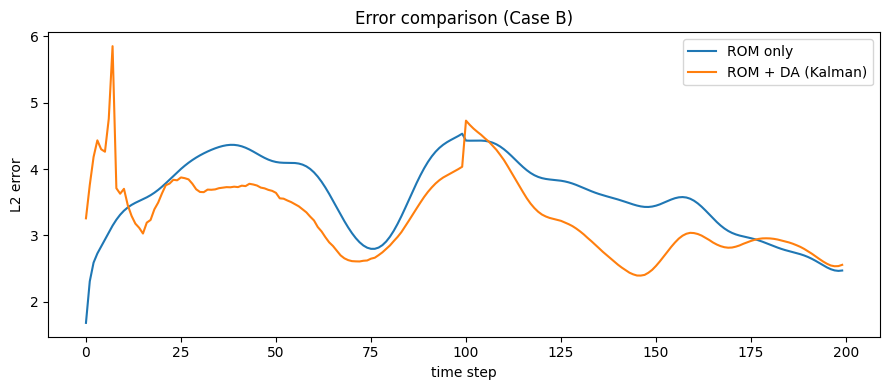

(array([1.6814748 , 2.30720577, 2.58966701, 2.7277825 , 2.83266883,
        2.93848738, 3.0457676 , 3.14707515, 3.23661429, 3.31192166,
        3.373072  , 3.42167605, 3.46021721, 3.4916546 , 3.51913179,
        3.54570019, 3.57404221, 3.60622308, 3.64351379, 3.68631922,
        3.73422454, 3.78614754, 3.84056383, 3.89576179, 3.95008492,
        4.00212847, 4.05086962, 4.09572303, 4.13652368, 4.17344751,
        4.20688642, 4.23729906, 4.26506156, 4.29034221, 4.31302044,
        4.33266383, 4.34856727, 4.35984871, 4.36558711, 4.36498282,
        4.35751766, 4.34309307, 4.3221265 , 4.29559052, 4.26498347,
        4.23222642, 4.19948893, 4.16895623, 4.14256199, 4.1217225 ,
        4.10711437, 4.0985362 , 4.09488192, 4.09423251, 4.09405011,
        4.09144112, 4.08344744, 4.06732777, 4.04080012, 4.0022275 ,
        3.95073915, 3.88628648, 3.80963728, 3.72231446, 3.62648673,
        3.52482054, 3.42030427, 3.31605903, 3.21515321, 3.120441  ,
        3.03444501, 2.95929863, 2.89675326, 2.84

In [421]:
run_test_caseB(snapshots, dt, r_rank=15, b_std=1e-3, r_std=0.1,
               init_error=False, use_inflation=False)


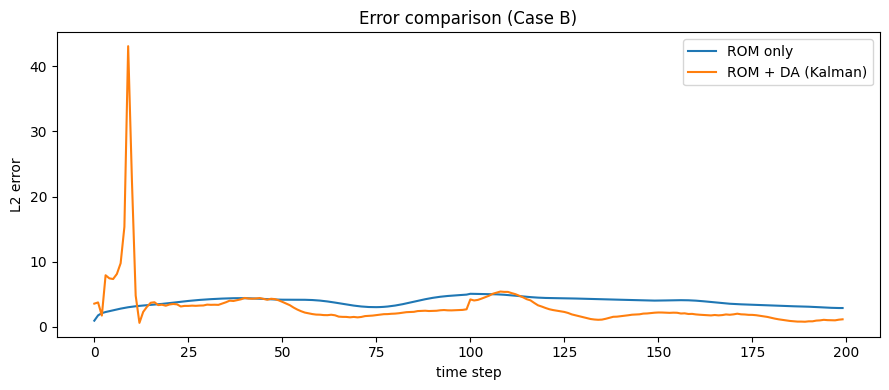

(array([0.94785347, 1.76107657, 2.10700019, 2.27613216, 2.40700997,
        2.53865655, 2.67141573, 2.7973475 , 2.91053316, 3.00862084,
        3.09186365, 3.16203722, 3.22174717, 3.27402106, 3.32201066,
        3.36871266, 3.41669598, 3.46786713, 3.52331513, 3.58326649,
        3.64715702, 3.71380245, 3.78163208, 3.84894201, 3.9141285 ,
        3.9758718 , 4.03325291, 4.08579743, 4.13344942, 4.17648609,
        4.21538978, 4.25069795, 4.28285494, 4.31208855, 4.33833152,
        4.36120068, 4.38003789, 4.39400658, 4.40222986, 4.40395027,
        4.39868879, 4.38638153, 4.36747461, 4.3429619 , 4.31435452,
        4.2835774 , 4.25279554, 4.22418298, 4.19965877, 4.18062545,
        4.16775153, 4.16083749, 4.15879209, 4.15972508, 4.16114054,
        4.16019788, 4.15400072, 4.13987612, 4.11561565, 4.07966056,
        4.03122305, 3.97034228, 3.89787856, 3.81545099, 3.72532603,
        3.63026533, 3.53334419, 3.43775448, 3.34661012, 3.26277578,
        3.18874013, 3.12655018, 3.07781253, 3.04

In [422]:
run_test_caseB(snapshots, dt, r_rank=15, b_std=1e-3, r_std=0.05,
               init_error=False, use_inflation=True,
               inflation_factor=1.15, inflation_thresh=3.0)


## Loader genérico de snapshots CFD

Esto es un esqueleto. Tendrás que adaptar la parte de lectura de ficheros a cómo exportes de tu CFD (VTK, CSV, numpy, lo que sea). Pero la estructura es la correcta.

In [ ]:
def load_cfd_snapshots(field_dir, field_name="U", mask=None):
    """
    field_dir: carpeta donde tienes los snapshots de CFD (ya convertidos a npy, csv o similar)
    field_name: "U" (velocidad) o "p" (presión) o combinado
    mask: array booleano o índices para seleccionar solo las celdas/nodos que te interesen
          (por ejemplo, una línea de corte o toda la malla)

    Devuelve:
        snapshots: array shape (n_state, n_snapshots)
    """

    # Aquí supongo que has guardado snapshots como npy: field_name_0000.npy, field_name_0001.npy, ...
    # Adapta esto a tu formato real.
    files = sorted(glob.glob(os.path.join(field_dir, f"{field_name}_*.npy")))
    if len(files) == 0:
        raise RuntimeError(f"No files found in {field_dir} for {field_name}_*.npy")

    snapshots_list = []
    for f in files:
        data = np.load(f)  # shape (Nx, Ny, [2 or 3] or scalar)

        # Aplana el campo en un vector 1D
        if data.ndim == 3:  # por ejemplo U(x,y,comp)
            # aquí puedes elegir solo la componente x, o apilar las dos
            # ejemplo: usar solo Ux
            field_vec = data[:, :, 0].ravel()
        else:
            field_vec = data.ravel()

        # aplicar máscara si te interesa seleccionar solo una parte del campo
        if mask is not None:
            field_vec = field_vec[mask]

        snapshots_list.append(field_vec)

    snapshots = np.stack(snapshots_list, axis=1)  # (n_state, n_snapshots)
    return snapshots


## Sensores sobre el cilindro (observación H_x)

Suponiendo que en tu CFD los nodos de la superficie del cilindro están identificados, puedes precomputar un vector de índices sensor_indices que apunten a esas celdas/nodos.

In [ ]:
def build_Hx_from_indices(n_state, sensor_indices):
    """
    n_state: tamaño del vector de estado (número de grados de libertad que usas en snapshots)
    sensor_indices: índices de las componentes del vector de estado que corresponden a sensores

    Devuelve:
        H_x: matriz de observación (n_sensors x n_state)
    """
    n_sensors = len(sensor_indices)
    H_x = np.zeros((n_sensors, n_state))
    for j, idx in enumerate(sensor_indices):
        H_x[j, idx] = 1.0
    return H_x
